# Лекция: Компьютерное зрение
## Self-Supervised Learning & Metric Learning

**Преподаватель:** Весельев Александр, Т-Банк

**Аудитория:** ФКН ВШЭ, МФТИ

---

## Содержание

1. self-supervised learning models
   1. SimCLR
   2. BYOL
   3. BEiT
   4. iBOT
   5. Dinov1
   6. Dinov2
   7. Dinov3
2. Contrastive Learning
   1. CLIP
   2. SigLIP
   3. SigLIP2
      1. linear probing
3. Metric Learning
   1. Tasks
      1. Verification
      2. Identification
         1. ReID
   2. Metrics
      1. RocAUC, TAR/FAR
      2. recall@k
      3. mAP
      4. CMC
      5. precision@k
   3. Triplet Loss
      1. HNM, OHNM
   4. FaceLoss
      1. CosFace
      2. SphereFace
      3. ArcFace
      4. AdaFace
      5. PartialFC
   5. ANN
      1. K-D tree
      2. HNSW
      3. LSH
      4. IVF-PQ
      5. Libs (Annoy, FAISS, HNSWlib, Qdrant)

## 1. Self-Supervised Learning

### 1.1 SimCLR

[arxiv](https://arxiv.org/abs/2002.05709)

![./assets/simclr.png](./assets/simclr.png)

**Идея**

Self-Supervised метод обучения:
- Учим сеть предсказывать одинаковые эмбединги для семантически одинаковых изображений (с разными аугментациями)


**Псевдокод**

```python
# input:
#   N   - batch size
#   tau - temperature constant
#   f   - encoder network
#   g   - projection head
#   T   - family of augmentations

for batch in dataloader:  # batch = {x_k}_{k=1}^N
    x = batch  # x[0], ..., x[N-1]

    h = [None] * (2 * N)
    z = [None] * (2 * N)

    for k in range(N):
        t1 = sample_augmentation(T)
        t2 = sample_augmentation(T)

        # first augmentation
        x_2k_1 = t1(x[k])
        h[2 * k] = f(x_2k_1)  # representation
        z[2 * k] = g(h[2 * k])  # projection

        # second augmentation
        x_2k = t2(x[k])
        h[2 * k + 1] = f(x_2k)  # representation
        z[2 * k + 1] = g(h[2 * k + 1])  # projection

    s = [[0.0 for _ in range(2 * N)] for _ in range(2 * N)]

    for i in range(2 * N):
        for j in range(2 * N):
            s[i][j] = cosine_similarity(z[i], z[j])

    def l(i, j):
        numerator = exp(s[i][j] / tau)

        denominator = 0.0
        for k in range(2 * N):
            if k != i:
                denominator += exp(s[i][k] / tau)

        return -log(numerator / denominator)

    L = 0.0
    for k in range(N):
        L += l(2 * k, 2 * k + 1) + l(2 * k + 1, 2 * k)

    L = L / (2 * N)

    update(f, g, loss=L)
return f
```

## 1.2 BYOL

[arxiv](https://arxiv.org/abs/2006.07733)

![./assets/byol.png](assets/byol.png)


**Идея**

Две аугментации одной и той же картинки: одна сеть (online) пытается предсказать представление второй (target), а вторая сеть даёт целевой вектор и обновляется не градиентом, а как медленная средняя от первой сети (EMA). Главное отличие от SimCLR: BYOL не использует negative pairs


**Псевдокод**
```python
# input:
#   D      - dataset
#   T, T2  - distributions of augmentations
#   f_o    - online encoder
#   g_o    - online projector
#   q_o    - online predictor
#   f_t    - target encoder
#   g_t    - target projector
#   tau_k  - EMA coefficient schedule
#   eta_k  - learning rate schedule

for k in range(1, K + 1):
    batch = sample_batch(D, size=N)

    losses = []

    for x in batch:
        t1 = sample_augmentation(T)
        t2 = sample_augmentation(T2)

        # two views of the same image
        v1 = t1(x)
        v2 = t2(x)

        # online network
        z1 = g_o(f_o(v1))
        z2 = g_o(f_o(v2))

        p1 = q_o(z1)
        p2 = q_o(z2)

        # target network
        z1_target = g_t(f_t(v1))
        z2_target = g_t(f_t(v2))

        # symmetrized loss
        loss_1 = -2 * cosine_similarity(p1, stop_gradient(z2_target))
        loss_2 = -2 * cosine_similarity(p2, stop_gradient(z1_target))

        loss = loss_1 + loss_2
        losses.append(loss)

    L = mean(losses)

    # update online network with gradient descent
    update_parameters([f_o, g_o, q_o], loss=L, lr=eta_k)

    # update target network with exponential moving average
    for param_t, param_o in zip(target_params, online_params):
        param_t = tau_k * param_t + (1 - tau_k) * param_o

# keep only the online encoder
return f_o
```

## 1.3 BEiT: BERT Pre-Training of Image Transformers

[arxiv](https://arxiv.org/abs/2106.08254)

![./assets/beit.png](./assets/beit.png)

**Идея**

Картинку режут на патчи, часть патчей маскируют, а модель должна угадать не сами пиксели, а дискретные "визуальные токены" для скрытых частей изображения. Эти токены заранее получает отдельный image tokenizer, обученный как dVAE (взято отсюда https://github.com/openai/DALL-E)

**Псевдокод**

```python
# input:
#   images            - training dataset
#   tokenizer         - pretrained image tokenizer
#   model             - Vision Transformer
#   mask_ratio        - fraction of patches to mask
#   optimizer         - optimizer for model parameters

for epoch in range(num_epochs):
    for image in dataloader(images):

        # 1. split image into patches
        patches = split_into_patches(image)

        # 2. get target visual tokens from tokenizer
        with no_grad():
            target_tokens = tokenizer.encode(image)

        # 3. sample masked patch positions
        masked_positions = sample_mask_positions(
            num_patches=len(patches),
            mask_ratio=mask_ratio
        )

        # 4. replace selected patches with [MASK]
        input_patches = []
        for i, patch in enumerate(patches):
            if i in masked_positions:
                input_patches.append(MASK_PATCH)
            else:
                input_patches.append(patch)

        # 5. encode visible + masked patches with ViT
        hidden_states = model(input_patches)

        # 6. predict visual tokens only for masked patches
        logits = predict_tokens(hidden_states)   # shape: num_patches x vocab_size

        # 7. compute loss only on masked positions
        loss = cross_entropy(
            logits[masked_positions],
            target_tokens[masked_positions]
        )

        # 8. update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# after pretraining, use the encoder for downstream tasks
return model.encoder
```

## 1.4 iBOT: Image BERT Pre-Training with Online Tokenizer

[arxiv](https://arxiv.org/abs/2111.07832)

![./assets/ibot.png](./assets/ibot.png)

**Идея**

Модель учится понимать всю картинку целиком и одновременно учится предсказывать скрытые патчи изображения. iBOT не нужен отдельный заранее обученный токенизатор, потому что teacher network сам выдаёт целевые токены для обучения

**Псевдокод**

```python
# input:
#   student_encoder
#   student_proj_cls       # projector/head for CLS token
#   student_proj_patch     # projector/head for patch tokens
#   teacher_encoder
#   teacher_proj_cls
#   teacher_proj_patch
#   mask_ratio
#   tau_s, tau_t           # temperatures for student / teacher
#   m                      # EMA momentum for teacher update

for batch in dataloader:
    loss_batch = 0.0

    for x in batch:
        # 1. sample two views of the same image
        view_s = strong_augmentation(x)   # for student
        view_t = weak_augmentation(x)     # for teacher

        # 2. create masked student input
        mask = sample_masked_patches(view_s, mask_ratio)
        masked_view_s = apply_mask(view_s, mask)

        # 3. forward pass through student
        cls_s, patch_s = student_encoder(masked_view_s)
        y_cls_s = student_proj_cls(cls_s)
        y_patch_s = student_proj_patch(patch_s)

        # 4. forward pass through teacher
        # teacher usually sees unmasked / less masked view
        with no_gradient():
            cls_t, patch_t = teacher_encoder(view_t)
            y_cls_t = teacher_proj_cls(cls_t)
            y_patch_t = teacher_proj_patch(patch_t)

        # 5. convert teacher outputs to targets
        target_cls = softmax(y_cls_t / tau_t)
        target_patch = softmax(y_patch_t / tau_t)

        # 6. convert student outputs to predictions
        pred_cls = log_softmax(y_cls_s / tau_s)
        pred_patch = log_softmax(y_patch_s / tau_s)

        # 7. global loss on CLS token
        loss_cls = cross_entropy(target_cls, pred_cls)

        # 8. patch loss only on masked positions
        loss_patch = 0.0
        for i in masked_positions(mask):
            loss_patch += cross_entropy(target_patch[i], pred_patch[i])
        loss_patch /= number_of_masked_positions(mask)

        # 9. total loss
        loss = loss_cls + loss_patch
        loss_batch += loss

    loss_batch /= len(batch)

    # 10. update student by gradient descent
    optimizer.zero_grad()
    loss_batch.backward()
    optimizer.step()

    # 11. update teacher by exponential moving average
    for theta_t, theta_s in zip(teacher_parameters, student_parameters):
        theta_t = m * theta_t + (1 - m) * theta_s

return student_encoder
```

## 1.5 Dino

### DinoV1

[arxiv](https://arxiv.org/abs/2104.14294)

![./assets/dinov1.png](assets/dinov1.png)

**Псевдокод**

```python
# gs : student network
# gt : teacher network
# C  : center vector, shape [K]
# tps: student temperature
# tpt: teacher temperature
# l  : teacher momentum
# m  : center momentum

gt.params = gs.params.copy()

for x in loader:
    x1 = augment(x)
    x2 = augment(x)

    s1 = gs(x1)  # student outputs, shape [n, K]
    s2 = gs(x2)

    t1 = gt(x1)  # teacher outputs, shape [n, K]
    t2 = gt(x2)

    loss = H(t1, s2) / 2 + H(t2, s1) / 2

    optimizer.zero_grad()
    loss.backward()  # back-propagate through student only
    optimizer.step()  # update student

    # teacher update: exponential moving average of student
    for p_t, p_s in zip(gt.params, gs.params):
        p_t.data = l * p_t.data + (1 - l) * p_s.data

    # center update
    batch_center = concat([t1, t2]).mean(dim=0)
    C = m * C + (1 - m) * batch_center


def H(t, s):
    t = detach(t)  # stop gradient on teacher
    s = softmax(s / tps, dim=1)  # student probabilities
    t = softmax((t - C) / tpt, dim=1)  # teacher centering + sharpening
    return -(t * log(s)).sum(dim=1).mean()
```

### DinoV2

[arxiv](https://arxiv.org/abs/2304.07193)

*Отличие с v1*

- на порядок больше данных (~142M изображений)
- добавлен patch-loss (iBOT)
- Sinkhorn-Knopp для teacher targets (замена centering)
- KoLEO регуляризация

### DinoV3

[arxiv](https://arxiv.org/abs/2508.10104)

*Отличие с v2*

- Еще больше данных (~1B изображений)
- Gram anchoring (модель учит взаимосвязь признаков)
- Обновление positional endoding, стабильнее обучение


In [ ]:
...

## 2. Contrastive Learning

*Небольшое напоминание*

### 2.1 CLIP

[arxiv](https://arxiv.org/abs/2103.00020)

![./assets/clip.png](./assets/clip.png)

### 2.2 SigLIP

[arxiv](https://arxiv.org/abs/2303.15343)

![./assets/siglip_1.png](./assets/siglip_1.png)

![./assets/siglip_2.png](./assets/siglip_2.png)

### 2.3 SigLIP 2

[arxiv](https://arxiv.org/abs/2502.14786)

![./assets/siglip2.png](./assets/siglip2.png)

In [ ]:
# thresholding

# linear probe

## 3. Metric Learning

### 3.1 Tasks

#### 3.1.1 Verification

- *"Это тот самый человек?"*
- 1 к 1 (one-to-one matching)

#### 3.1.2 Identification

- *"Кто это вообще?"*
- 1 ко многим (one-to-many matching)

#### 3.1.3 ReID

![./assets/reid.png](./assets/reid.png)


## 3.2 Metrics

#### 1. ROC-AUC, TAR / FAR

Основная метрика для задачи верификации

* **TAR (True Accept Rate)** `== TPR`
* **FAR (False Accept Rate)** `== FPR`

#### 2. Recall@K

> Есть ли **хотя бы один правильный ответ** в топ-K?

```
Recall@K = 1, если правильный есть в top-K
         = 0 иначе
```

#### 3. mAP (mean Average Precision)


- **Precision@k**

$$
Precision@k = \frac{\text{\#релевантных в top-k}}{k}
$$

- **Average Precision (AP)**

$$
AP = \frac{1}{R} \sum_{k=1}^{N} Precision@k \cdot rel(k)
$$

где:

* (R) — число релевантных объектов
* (rel(k) = 1), если на позиции (k) релевантный, иначе 0

- **mAP**

$$
mAP = \frac{1}{Q} \sum_{q=1}^{Q} AP_q
$$

где:

* (Q) — число запросов


#### 4. CMC (Cumulative Matching Characteristic)

```
 CMC(k)=P(первый правильный match находится на позиции <= k)
```

- Если на каждый запрос ровно 1 правильный ответ то `CMC@K == Recall@K`


#### 5. Precision@K

```
Precision@K = (# релевантных в top-K) / K
```



## 3.3 Triplet Loss

![./assets/triplet.png](./assets/triplet.png)

$$
\mathcal{L} = \max\left( d(a, p) - d(a, n) + \alpha; 0 \right)
$$

* $a$: anchor
* $p$: positive
* $n$: negative
* $d(\cdot, \cdot)$: функция расстояния
* $\alpha$: margin (небольшая положительная константа)

Хотим
$$
d(a, p) + \alpha < d(a, n)
$$


```python
import torch
import torch.nn.functional as F

def triplet_loss(anchor, positive, negative, margin=1.0):
    pos_dist = F.pairwise_distance(anchor, positive, p=2)
    neg_dist = F.pairwise_distance(anchor, negative, p=2)
    
    loss = torch.relu(pos_dist - neg_dist + margin)
    
    return loss.mean()
```

## 3.3.1 Hard Negative Mining

В триплетах $(a, p, n)$:

* **easy negative**: $d(a,n) \gg d(a,p) \rightarrow loss = 0$ (бесполезно)
* **hard negative**: $d(a,n) < d(a,p)$
* **semi-hard negative**: $d(a,p) < d(a,n) < d(a,p)+margin$

Hard negative mining = выбирать такие $n$, для которых loss максимальный. Мы хотим выбирать негативы, которые максимизируют: $d(a,p) - d(a,n)$

*Проблема*

* Полный перебор всех негативов очень дорого
* Можно выбрать слишком сложные примеры: обучение становится нестабильным (шум, аномалии)

## 3.3.2 Online Hard Negative Mining

*Идея:* выбирать hard-негативы прямо внутри текущего батча (on-the-fly)

1. Берём batch
2. Считаем все попарные расстояния
3. Для каждого anchor:
   * выбираем:
     * hardest positive
     * hardest negative
     
**Batch-hard triplet loss**

$$
\mathcal{L} = \max\left( \max_{p} d(a,p) - \min_{n} d(a,n) + \alpha,; 0 \right)
$$


```python
def batch_hard_triplet_loss(embeddings, labels, margin=1.0):
    # pairwise distance matrix
    dist = torch.cdist(embeddings, embeddings, p=2)

    loss = 0.0
    N = embeddings.size(0)

    for i in range(N):
        anchor_label = labels[i]

        # mask for positives and negatives
        pos_mask = labels == anchor_label
        neg_mask = labels != anchor_label

        pos_dist = dist[i][pos_mask]
        neg_dist = dist[i][neg_mask]

        hardest_pos = pos_dist.max()
        hardest_neg = neg_dist.min()

        loss += torch.relu(hardest_pos - hardest_neg + margin)

    return loss / N
```

## 4 FaceLoss

**arcface**

[arxiv](https://arxiv.org/pdf/1801.07698v3)

![./assets/arcface.png](./assets/arcface.png)

$$
\mathcal{L} = - \log \frac{e^{s \cdot \cos(\theta_y + m)}}{e^{s \cdot \cos(\theta_y + m)} + \sum_{j \ne y} e^{s \cdot \cos(\theta_j)}}
$$

**CosFace**

[arxiv](https://arxiv.org/abs/1801.09414)

$$
\mathcal{L}_{\text{CosFace}} = - \log
  \frac{e^{s \cdot (\cos(\theta_y) - m)}}
  {e^{s \cdot (\cos(\theta_y) - m)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**SphereFace**

[arxiv](https://arxiv.org/abs/1704.08063)

$$
\mathcal{L}_{\text{SphereFace}} =

- \log
  \frac{e^{s \cdot \cos(m \theta_y)}}
  {e^{s \cdot \cos(m \theta_y)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**Combined Loss (ArcFace + CosFace + SphereFace)**

$$
\mathcal{L}_{\text{Combined}} =

- \log
  \frac{e^{s \cdot (\cos(m_1 \theta_y + m_2) - m_3)}}
  {e^{s \cdot (\cos(m_1 \theta_y + m_2) - m_3)} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

**AdaFace**

[arxiv](https://arxiv.org/pdf/2204.00964)

$$
\mathcal{L}_{\text{AdaFace}} = - \log
  \frac{e^{s \cdot \cos(\theta_y + m(|x|))}}
  {e^{s \cdot \cos(\theta_y + m(|x|))} + \sum_{j \ne y} e^{s \cdot \cos\theta_j}}
$$

$$
m(|x|) = m \cdot \frac{|x| - \mu}{\sigma}
$$

---

p.s. [partialfc](https://arxiv.org/abs/2010.05222) как обучать модель с большим числом классов

---

In [1]:
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18




In [3]:
@dataclass
class Config:
    data_root: str = "./data"
    batch_size: int = 256
    epochs: int = 100
    lr: float = 6e-4
    weight_decay: float = 1e-3

    num_identities: int = 8
    lfw_min_faces_for_pool: int = 20
    lfw_subset_min_count: int = 50
    test_size: float = 0.3
    lfw_resize: float = 0.8

    embedding_dim: int = 2
    norm_scale_s: float = 16.0
    arc_scale_s: float = 16.0
    arc_margin_m: float = 0.5
    arc_margin_warmup_epochs: int = 10

    norm_points_to_plot_per_class: int = 80
    arc_points_to_plot_per_class: int = 80

    seed: int = 42
    num_workers: int = 2
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


In [4]:
# helpers
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def plot_embeddings(ax, emb, labels, weight, title, max_points):
    colors = plt.cm.tab10(np.linspace(0, 1, weight.shape[0]))

    for c in range(weight.shape[0]):
        pts = emb[labels == c]
        if len(pts) > max_points:
            idx = np.random.choice(len(pts), max_points, replace=False)
            pts = pts[idx]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.9, color=colors[c], linewidths=0)

    for c in range(weight.shape[0]):
        w = weight[c]
        ax.plot([0, w[0]], [0, w[1]], linewidth=2, color=colors[c])

    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.axis("off")


# dataset prepare utils
def choose_balanced_identities(
    targets: np.ndarray, k: int, min_count: int
) -> tuple[int, ...]:
    counts = np.bincount(targets)
    valid = np.where(counts >= min_count)[0]
    if len(valid) < k:
        raise ValueError(
            f"Not enough identities with >= {min_count} samples; found {len(valid)}"
         )
    valid = valid[np.argsort(counts[valid])]
    best = None
    best_score = None
    for i in range(0, len(valid) - k + 1):
        window = valid[i : i + k]
        w_counts = counts[window]
        spread = int(w_counts.max() - w_counts.min())
        mean_count = float(w_counts.mean())
        score = (spread, -mean_count)
        if best_score is None or score < best_score:
            best_score = score
            best = window

    return tuple(int(i) for i in best)


def remap_subset(
    targets: np.ndarray, chosen: tuple[int, ...]
) -> tuple[np.ndarray, np.ndarray]:
    chosen_arr = np.asarray(chosen)
    keep_mask = np.isin(targets, chosen_arr)
    targets_kept = targets[keep_mask]
    old_to_new = {old: new for new, old in enumerate(chosen)}
    targets_new = np.asarray([old_to_new[int(t)] for t in targets_kept], dtype=np.int64)
    return keep_mask, targets_new


def preprocess_for_resnet(batch_gray: torch.Tensor) -> torch.Tensor:
    x = batch_gray.unsqueeze(1)  # [B,1,H,W]
    x = x.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std


@torch.no_grad()
def extract_backbone_features(
    images: np.ndarray, device: str, batch_size: int = 128
) -> torch.Tensor:
    weights = ResNet18_Weights.IMAGENET1K_V1
    backbone = resnet18(weights=weights)
    backbone.fc = nn.Identity()
    backbone.eval().to(device)

    feats = []
    images_t = torch.from_numpy(images.astype(np.float32))
    for s in range(0, len(images_t), batch_size):
        batch = images_t[s : s + batch_size].to(device, non_blocking=True)
        batch = preprocess_for_resnet(batch)
        feats.append(backbone(batch).cpu())
    return torch.cat(feats, dim=0)


def build_feature_dataloaders(cfg: Config):
    lfw = fetch_lfw_people(
        data_home=cfg.data_root,
        min_faces_per_person=cfg.lfw_min_faces_for_pool,
        resize=cfg.lfw_resize,
        color=False,
        download_if_missing=True,
    )

    images = lfw.images.astype(np.float32)
    targets = lfw.target.astype(np.int64)

    chosen = choose_balanced_identities(
        targets,
        k=cfg.num_identities,
        min_count=cfg.lfw_subset_min_count,
    )
    keep_mask, targets_new = remap_subset(targets, chosen)
    images = images[keep_mask]

    chosen_names = [str(lfw.target_names[c]) for c in chosen]
    raw_counts = np.bincount(targets[keep_mask])
    counts_map = {str(lfw.target_names[c]): int(raw_counts[c]) for c in chosen}
    print(f"Chosen identities: {chosen_names}")
    print(f"Samples per chosen identity: {counts_map}")

    idx_all = np.arange(len(targets_new))
    train_idx, test_idx = train_test_split(
        idx_all,
        test_size=cfg.test_size,
        random_state=cfg.seed,
        stratify=targets_new,
    )

    train_images = images[train_idx]
    train_labels = torch.from_numpy(targets_new[train_idx])
    test_images = images[test_idx]
    test_labels = torch.from_numpy(targets_new[test_idx])

    print("Extracting frozen backbone features...")
    train_feats = extract_backbone_features(train_images, cfg.device)
    test_feats = extract_backbone_features(test_images, cfg.device)

    train_ds = TensorDataset(train_feats, train_labels)
    test_ds = TensorDataset(test_feats, test_labels)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=True,
    )

    return train_loader, test_loader, train_feats.shape[1], chosen_names


# models
class FeatureEmbedder(nn.Module):
    def __init__(self, in_dim: int, embedding_dim: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.PReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, embedding_dim),
        )

    def forward(self, x):
        z = self.net(x)
        return F.normalize(z, p=2, dim=1)


class NormSoftmaxHead(nn.Module):
    def __init__(self, embedding_dim: int, num_classes: int, s: float = 16.0):
        super().__init__()
        self.s = s
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb: torch.Tensor):
        weight = F.normalize(self.weight, p=2, dim=1)
        return self.s * F.linear(emb, weight)


class ArcFaceHead(nn.Module):
    def __init__(
        self, embedding_dim: int, num_classes: int, s: float = 32.0, m: float = 0.4
    ):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.empty(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self._update_consts()

    def _update_consts(self):
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)

    def set_margin(self, margin: float):
        self.m = margin
        self._update_consts()

    def forward(self, emb: torch.Tensor, labels: torch.Tensor | None = None):
        w = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(emb, w).clamp(-1.0 + 1e-7, 1.0 - 1e-7)
        if labels is None:
            return self.s * cosine

        sine = torch.sqrt(1.0 - cosine.pow(2))
        phi = cosine * self.cos_m - sine * self.sin_m

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        
        return (one_hot * phi + (1.0 - one_hot) * cosine) * self.s


class NormSoftmaxModel(nn.Module):
    def __init__(self, in_dim: int, embedding_dim: int, num_classes: int, s: float):
        super().__init__()
        self.embedder = FeatureEmbedder(in_dim, embedding_dim)
        self.head = NormSoftmaxHead(embedding_dim, num_classes, s)

    def forward(self, x, *_, **__):
        emb = self.embedder(x)
        logits = self.head(emb)
        return logits, emb


class ArcFaceModel(nn.Module):
    def __init__(
        self, in_dim: int, embedding_dim: int, num_classes: int, s: float, m: float
    ):
        super().__init__()
        self.embedder = FeatureEmbedder(in_dim, embedding_dim)
        self.head = ArcFaceHead(embedding_dim, num_classes, s, m)

    def forward(self, x, labels=None):
        emb = self.embedder(x)
        logits = self.head(emb, labels)
        return logits, emb


Config(data_root='./data', batch_size=256, epochs=100, lr=0.0006, weight_decay=0.001, num_identities=8, lfw_min_faces_for_pool=20, lfw_subset_min_count=50, test_size=0.3, lfw_resize=0.8, embedding_dim=2, norm_scale_s=16.0, arc_scale_s=16.0, arc_margin_m=0.5, arc_margin_warmup_epochs=10, norm_points_to_plot_per_class=80, arc_points_to_plot_per_class=80, seed=42, num_workers=2, device='cuda')
Chosen identities: ['Jacques Chirac', 'Serena Williams', 'John Ashcroft', 'Jean Chretien', 'Junichiro Koizumi', 'Hugo Chavez', 'Ariel Sharon', 'Gerhard Schroeder']
Samples per chosen identity: {'Jacques Chirac': 52, 'Serena Williams': 52, 'John Ashcroft': 53, 'Jean Chretien': 55, 'Junichiro Koizumi': 60, 'Hugo Chavez': 71, 'Ariel Sharon': 77, 'Gerhard Schroeder': 109}
Extracting frozen backbone features...

Training Norm-Softmax
[NormSoftmax] epoch 01/100 | train loss=14.0509 acc=0.1649 | test loss=12.8509 acc=0.2013
[NormSoftmax] epoch 02/100 | train loss=8.8660 acc=0.2541 | test loss=9.2267 acc=0.

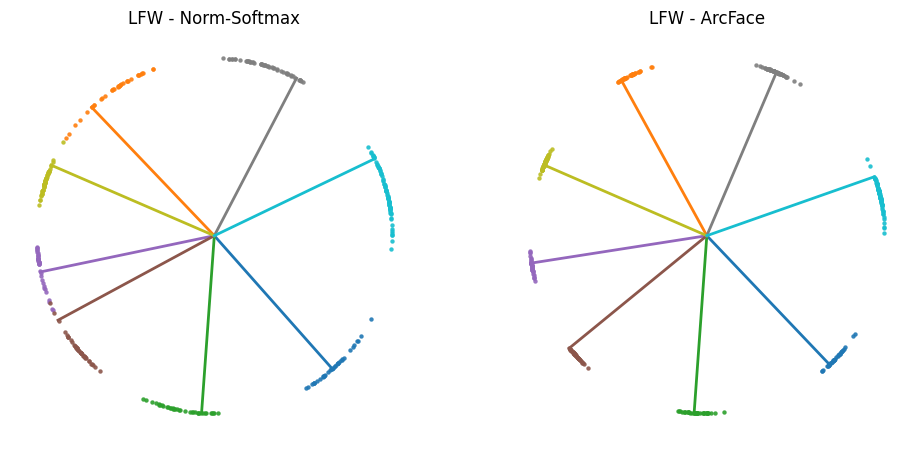

In [5]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = total_acc = total = 0
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(feats, labels)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * feats.size(0)
        total_acc += (logits.argmax(dim=1) == labels).sum().item()
        total += feats.size(0)

    return total_loss / total, total_acc / total


@torch.no_grad()
def evaluate(model, loader, device, use_arcface: bool):
    model.eval()
    total_loss = total_acc = total = 0
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_arcface:
            logits, _ = model(feats, labels)
        else:
            logits, _ = model(feats)

        loss = F.cross_entropy(logits, labels)
        total_loss += loss.item() * feats.size(0)
        total_acc += (logits.argmax(dim=1) == labels).sum().item()
        total += feats.size(0)

    return total_loss / total, total_acc / total


@torch.no_grad()
def collect_embeddings(model, loader, device):
    model.eval()
    all_emb, all_y = [], []
    for feats, labels in loader:
        feats = feats.to(device, non_blocking=True)
        emb = model.embedder(feats)
        all_emb.append(emb.cpu())
        all_y.append(labels)

    emb = torch.cat(all_emb, dim=0).numpy()
    y = torch.cat(all_y, dim=0).numpy()
    w = F.normalize(model.head.weight.detach().cpu(), p=2, dim=1).numpy()
    return emb, y, w


def train_arcface_vs_normsoftmax():
    cfg = Config()
    set_seed(cfg.seed)
    print(cfg)

    train_loader, test_loader, in_dim, chosen_names = build_feature_dataloaders(cfg)

    norm_model = NormSoftmaxModel(
        in_dim, cfg.embedding_dim, cfg.num_identities, cfg.norm_scale_s
    ).to(cfg.device)
    arc_model = ArcFaceModel(
        in_dim, cfg.embedding_dim, cfg.num_identities, cfg.arc_scale_s, cfg.arc_margin_m
    ).to(cfg.device)
    norm_optim = torch.optim.AdamW(
        norm_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    arc_optim = torch.optim.AdamW(
        arc_model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )

    print("\nTraining Norm-Softmax")
    best_norm_state = None
    best_norm_te_acc = -1.0
    for epoch in range(cfg.epochs):
        tr_loss, tr_acc = train_one_epoch(
            norm_model,
            train_loader,
            norm_optim,
            cfg.device,
        )
        te_loss, te_acc = evaluate(
            norm_model, test_loader, cfg.device, use_arcface=False
        )
        if te_acc > best_norm_te_acc:
            best_norm_te_acc = te_acc
            best_norm_state = {
                k: v.detach().cpu().clone() for k, v in norm_model.state_dict().items()
            }

        print(
            f"[NormSoftmax] epoch {epoch+1:02d}/{cfg.epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} | test loss={te_loss:.4f} acc={te_acc:.4f}"
        )

    print("\nTraining ArcFace")
    arc_model.embedder.load_state_dict(norm_model.embedder.state_dict())
    arc_model.head.weight.data.copy_(norm_model.head.weight.data)
    best_arc_state = None
    best_arc_te_acc = -1.0
    for epoch in range(cfg.epochs):
        warmup = min(1.0, (epoch + 1) / cfg.arc_margin_warmup_epochs)
        arc_model.head.set_margin(cfg.arc_margin_m * warmup)
        tr_loss, tr_acc = train_one_epoch(
            arc_model, train_loader, arc_optim, cfg.device
        )
        te_loss, te_acc = evaluate(
            arc_model, test_loader, cfg.device, use_arcface=False
        )
        if te_acc > best_arc_te_acc:
            best_arc_te_acc = te_acc
            best_arc_state = {
                k: v.detach().cpu().clone() for k, v in arc_model.state_dict().items()
            }
        print(
            f"[ArcFace] epoch {epoch+1:02d}/{cfg.epochs} | m={arc_model.head.m:.3f} | "
            f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | test loss={te_loss:.4f} acc={te_acc:.4f}"
        )
    if best_arc_state is not None:
        arc_model.load_state_dict(best_arc_state)
    print(
        f"[ArcFace final] best test acc={best_arc_te_acc:.4f} "
        f"with s={cfg.arc_scale_s:.1f}, m={cfg.arc_margin_m:.2f}, lr={cfg.lr:.0e}"
    )
    if best_norm_state is not None:
        norm_model.load_state_dict(best_norm_state)
    print(
        f"[NormSoftmax final] best test acc={best_norm_te_acc:.4f} "
        f"with s={cfg.norm_scale_s:.1f}, lr={cfg.lr:.0e}"
    )

    emb_norm, y_norm, w_norm = collect_embeddings(norm_model, train_loader, cfg.device)
    emb_arc, y_arc, w_arc = collect_embeddings(arc_model, train_loader, cfg.device)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
    plot_embeddings(
        axes[0],
        emb_norm,
        y_norm,
        w_norm,
        title="LFW - Norm-Softmax",
        max_points=cfg.norm_points_to_plot_per_class,
    )
    plot_embeddings(
        axes[1],
        emb_arc,
        y_arc,
        w_arc,
        title="LFW - ArcFace",
        max_points=cfg.arc_points_to_plot_per_class,
    )

    plt.tight_layout()
    plt.show()

train_arcface_vs_normsoftmax()

## 5 ANN

- K-D tree
- HNSW
- LSH
- IVF-PQ (https://milvus.io/docs/ivf-pq.md)


- Annoy
- FAISS
- HNSWlib
- Qdrant

In [8]:
from pytorch_metric_learning import datasets

In [20]:
train_dataset = datasets.CUB(root="data", 
    split="train", 
    transform=None, 
    target_transform=None, 
    download=True
)
# No need to download the dataset after it is already downladed
test_dataset = datasets.CUB(root="data", 
    split="test", 
    transform=None, 
    target_transform=None, 
    download=True
)
# train_and_test_dataset = datasets.CUB(root="data", 
#     split="train+test", 
#     transform=None, 
#     target_transform=None, 
#     download=False
# ) 

In [1]:
import torch
from transformers import AutoProcessor, AutoModel
from PIL import Image

MODEL_NAME = "google/siglip-base-patch16-224"

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()


model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SiglipModel(
  (text_model): SiglipTextTransformer(
    (embeddings): SiglipTextEmbeddings(
      (token_embedding): Embedding(32000, 768)
      (position_embedding): Embedding(64, 768)
    )
    (encoder): SiglipEncoder(
      (layers): ModuleList(
        (0-11): 12 x SiglipEncoderLayer(
          (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attn): SiglipAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): SiglipMLP(
            (activation_fn): GELUTanh()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features

In [5]:
import requests


with open("pomeranian.png", "wb") as f:
    f.write(requests.get("https://content.lyka.com.au/f/1016262/676x676/ccffa6a4b8/pomeranian.png/m/1280x0/filters:format(webp)").content)

In [7]:

image = Image.open("pomeranian.png").convert("RGB")
texts = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a car",
    "a photo of a pomeranian dog",
]

# Для SigLIP важно padding="max_length"
inputs = processor(
    text=texts,
    images=image,
    padding="max_length",
    return_tensors="pt",
)

inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

    # logits_per_image: shape [num_images, num_texts]
    logits = outputs.logits_per_image

    # pairwise probabilities
    probs = torch.sigmoid(logits)

print("Logits:", logits.cpu())
print("Probabilities:", probs.cpu())

for text, p in zip(texts, probs[0].cpu().tolist()):
    print(f"{text:20s} -> {p:.4f}")

Logits: tensor([[ -8.8095,  -3.1312, -12.2744,   0.6720]])
Probabilities: tensor([[1.4929e-04, 4.1839e-02, 4.6697e-06, 6.6195e-01]])
a photo of a cat     -> 0.0001
a photo of a dog     -> 0.0418
a photo of a car     -> 0.0000
a photo of a pomeranian dog -> 0.6620


In [6]:
import argparse
import json
import math
import os
import random
from dataclasses import asdict, dataclass

import numpy as np
import timm
import torch
import torch.nn as nn
from datasets import load_dataset
from PIL import Image
from timm.data import create_transform, resolve_model_data_config
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm import tqdm


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class HFDatasetWrapper(Dataset):
    def __init__(self, hf_dataset, transform):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]
        image = sample["image"]
        label = sample["labels"]

        if not isinstance(image, Image.Image):
            raise TypeError(f"Expected PIL image, got {type(image)}")

        image = image.convert("RGB")
        image = self.transform(image)
        return image, label


class LinearClassifier(nn.Module):
    def __init__(self, in_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


@dataclass
class Metrics:
    loss: float
    acc1: float


def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


@torch.no_grad()
def extract_features(
    backbone: nn.Module,
    loader: DataLoader,
    device: torch.device,
    normalize: bool = False,
):
    backbone.eval()

    all_features = []
    all_labels = []

    pbar = tqdm(loader, desc="extract_features", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        feats = backbone(images)

        if normalize:
            feats = torch.nn.functional.normalize(feats, dim=1)

        all_features.append(feats.cpu())
        all_labels.append(labels.clone())

    features = torch.cat(all_features, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return features, labels


def train_one_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0
    total = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        bs = features.size(0)
        running_loss += loss.item() * bs
        running_acc += accuracy(logits.detach(), targets) * bs
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{running_acc / total:.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )

    return Metrics(
        loss=running_loss / total,
        acc1=running_acc / total,
    )


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0
    total = 0

    pbar = tqdm(loader, desc="eval", leave=False)
    for features, targets in pbar:
        features = features.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(features)
        loss = criterion(logits, targets)

        bs = features.size(0)
        running_loss += loss.item() * bs
        running_acc += accuracy(logits, targets) * bs
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{running_acc / total:.4f}",
        )

    return Metrics(
        loss=running_loss / total,
        acc1=running_acc / total,
    )


def save_json(obj, path: str):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def linear_probe():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--model-name",
        type=str,
        default="vit_small_patch14_dinov2.lvd142m",
        help="timm model name",
    )
    parser.add_argument(
        "--dataset-name",
        type=str,
        default="Bingsu/Human_Action_Recognition",
    )
    parser.add_argument("--eval-size", type=float, default=0.2)
    parser.add_argument("--seed", type=int, default=42)

    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument(
        "--batch-size",
        type=int,
        default=256,
        help="batch size for linear head training on cached features",
    )
    parser.add_argument(
        "--feature-batch-size",
        type=int,
        default=64,
        help="batch size for backbone feature extraction",
    )
    parser.add_argument("--num-workers", type=int, default=4)

    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--min-lr", type=float, default=1e-6)
    parser.add_argument("--weight-decay", type=float, default=1e-4)

    parser.add_argument(
        "--normalize-features",
        action="store_true",
        help="L2-normalize cached features before classifier training",
    )
    parser.add_argument(
        "--cache-dir",
        type=str,
        default=None,
        help="directory to save/load cached train/eval features",
    )
    parser.add_argument(
        "--recompute-cache",
        action="store_true",
        help="force recomputation even if cache files exist",
    )
    parser.add_argument(
        "--output-dir", type=str, default="./outputs/linear_probe_cached_har"
    )

    args = parser.parse_args()
    os.makedirs(args.output_dir, exist_ok=True)
    if args.cache_dir is not None:
        os.makedirs(args.cache_dir, exist_ok=True)

    set_seed(args.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load only the train split, then split into train/eval.
    ds = load_dataset(args.dataset_name, split="train")
    ds_split = ds.train_test_split(
        test_size=args.eval_size,
        seed=args.seed,
        stratify_by_column="labels",
    )
    train_ds_hf = ds_split["train"]
    eval_ds_hf = ds_split["test"]

    label_feature = ds.features["labels"]
    class_names = label_feature.names
    num_classes = label_feature.num_classes

    print(f"Classes ({num_classes}): {class_names}")
    print(f"Train samples: {len(train_ds_hf)}")
    print(f"Eval samples:  {len(eval_ds_hf)}")

    # Create backbone and transforms.
    backbone = timm.create_model(
        args.model_name,
        pretrained=True,
        num_classes=0,
    ).to(device)
    backbone.eval()

    feature_dim = backbone.num_features
    print(f"Backbone feature dim: {feature_dim}")

    data_config = resolve_model_data_config(backbone)
    train_transform = create_transform(**data_config, is_training=True)
    eval_transform = create_transform(**data_config, is_training=False)

    train_img_ds = HFDatasetWrapper(train_ds_hf, train_transform)
    eval_img_ds = HFDatasetWrapper(eval_ds_hf, eval_transform)

    train_img_loader = DataLoader(
        train_img_ds,
        batch_size=args.feature_batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )
    eval_img_loader = DataLoader(
        eval_img_ds,
        batch_size=args.feature_batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )

    cache_enabled = args.cache_dir is not None
    cache_key = (
        f"{args.dataset_name.replace('/', '_')}"
        f"__{args.model_name.replace('/', '_')}"
        f"__seed{args.seed}"
        f"__eval{args.eval_size}"
        f"__norm{int(args.normalize_features)}"
    )

    train_cache_path = None
    eval_cache_path = None
    if cache_enabled:
        train_cache_path = os.path.join(args.cache_dir, f"{cache_key}__train.pt")
        eval_cache_path = os.path.join(args.cache_dir, f"{cache_key}__eval.pt")

    # Load or compute cached features.
    if (
        cache_enabled
        and not args.recompute_cache
        and os.path.exists(train_cache_path)
        and os.path.exists(eval_cache_path)
    ):
        print("Loading cached features...")
        train_cache = torch.load(train_cache_path, map_location="cpu")
        eval_cache = torch.load(eval_cache_path, map_location="cpu")

        train_features = train_cache["features"]
        train_labels = train_cache["labels"]
        eval_features = eval_cache["features"]
        eval_labels = eval_cache["labels"]
    else:
        print("Extracting train features...")
        train_features, train_labels = extract_features(
            backbone=backbone,
            loader=train_img_loader,
            device=device,
            normalize=args.normalize_features,
        )

        print("Extracting eval features...")
        eval_features, eval_labels = extract_features(
            backbone=backbone,
            loader=eval_img_loader,
            device=device,
            normalize=args.normalize_features,
        )

        if cache_enabled:
            print("Saving cached features...")
            torch.save(
                {
                    "features": train_features,
                    "labels": train_labels,
                    "class_names": class_names,
                    "feature_dim": feature_dim,
                    "model_name": args.model_name,
                    "dataset_name": args.dataset_name,
                },
                train_cache_path,
            )
            torch.save(
                {
                    "features": eval_features,
                    "labels": eval_labels,
                    "class_names": class_names,
                    "feature_dim": feature_dim,
                    "model_name": args.model_name,
                    "dataset_name": args.dataset_name,
                },
                eval_cache_path,
            )

    # Free backbone memory after caching.
    del backbone
    if device.type == "cuda":
        torch.cuda.empty_cache()

    train_feat_ds = TensorDataset(train_features, train_labels)
    eval_feat_ds = TensorDataset(eval_features, eval_labels)

    train_feat_loader = DataLoader(
        train_feat_ds,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )
    eval_feat_loader = DataLoader(
        eval_feat_ds,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=(device.type == "cuda"),
        drop_last=False,
    )

    model = LinearClassifier(feature_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=args.lr,
        weight_decay=args.weight_decay,
    )

    total_steps = args.epochs * len(train_feat_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=total_steps,
        eta_min=args.min_lr,
    )

    print(
        f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
    )
    print(f"Total optimization steps: {total_steps}")

    best_acc = -math.inf
    history = []

    for epoch in range(1, args.epochs + 1):
        print(f"\nEpoch {epoch}/{args.epochs}")

        train_metrics = train_one_epoch(
            model=model,
            loader=train_feat_loader,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            device=device,
        )
        eval_metrics = evaluate(
            model=model,
            loader=eval_feat_loader,
            criterion=criterion,
            device=device,
        )

        epoch_stats = {
            "epoch": epoch,
            "train": asdict(train_metrics),
            "eval": asdict(eval_metrics),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(epoch_stats)

        print(
            f"train_loss={train_metrics.loss:.4f} "
            f"train_acc={train_metrics.acc1:.4f} | "
            f"eval_loss={eval_metrics.loss:.4f} "
            f"eval_acc={eval_metrics.acc1:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.8f}"
        )

        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "args": vars(args),
            "class_names": class_names,
            "feature_dim": feature_dim,
            "history": history,
        }

        torch.save(ckpt, os.path.join(args.output_dir, "last.pt"))

        if eval_metrics.acc1 > best_acc:
            best_acc = eval_metrics.acc1
            torch.save(ckpt, os.path.join(args.output_dir, "best.pt"))
            print(f"Saved new best checkpoint with eval_acc={best_acc:.4f}")

        save_json(
            {
                "args": vars(args),
                "class_names": class_names,
                "feature_dim": feature_dim,
                "best_eval_acc": best_acc,
                "history": history,
            },
            os.path.join(args.output_dir, "metrics.json"),
        )

    print("\nDone.")
    print(f"Best eval accuracy: {best_acc:.4f}")
    print(f"Artifacts saved to: {args.output_dir}")


linear_probe()

usage: ipykernel_launcher.py [-h] [--model-name MODEL_NAME]
                             [--dataset-name DATASET_NAME]
                             [--eval-size EVAL_SIZE] [--seed SEED]
                             [--epochs EPOCHS] [--batch-size BATCH_SIZE]
                             [--feature-batch-size FEATURE_BATCH_SIZE]
                             [--num-workers NUM_WORKERS] [--lr LR]
                             [--min-lr MIN_LR] [--weight-decay WEIGHT_DECAY]
                             [--normalize-features] [--cache-dir CACHE_DIR]
                             [--recompute-cache] [--output-dir OUTPUT_DIR]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/podidiving/.local/share/jupyter/runtime/kernel-3c7d1d70-73c8-4354-b06e-95573c3d8538.json


SystemExit: 2

/home/podidiving/Develop/CV-HSE-MIPT-Course-2026-spring/lesson_7/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3755: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
